In [19]:
# CÉLULA 1: Preparando o ambiente

!pip install tensorflow-datasets opencv-python matplotlib seaborn scikit-learn -q

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

print("Ambiente configurado")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

Ambiente configurado
GPU disponível: []


In [20]:
# CÉLULA 2: Carregando o dataset PlantVillage (completo)

print("Carregando dataset...")
dataset, info = tfds.load('plant_village', split='train', with_info=True, as_supervised=True)

nomes_classes = info.features['label'].names
print(f"Total de imagens: {info.splits['train'].num_examples:,}")
print(f"Total de classes: {len(nomes_classes)}")

print("\nPrimeiras classes disponíveis:")
for i in range(min(10, len(nomes_classes))):
    print(f"  {i}: {nomes_classes[i]}")

Carregando dataset...
Total de imagens: 54,303
Total de classes: 38

Primeiras classes disponíveis:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy
  5: Cherry___healthy
  6: Cherry___Powdery_mildew
  7: Corn___Cercospora_leaf_spot Gray_leaf_spot
  8: Corn___Common_rust
  9: Corn___healthy


In [21]:
# CÉLULA 3: Selecionando algumas classes para começar
# Vou usar classes de maçã que são bem representadas no dataset

classes_maca = [nome for nome in nomes_classes if nome.startswith('Apple')]
print(f"Classes de maçã encontradas: {classes_maca}")

CLASSES_SELECIONADAS = classes_maca[:3]
print(f"Classes que vou usar: {CLASSES_SELECIONADAS}")

indices_selecionados = [nomes_classes.index(nome) for nome in CLASSES_SELECIONADAS]

Classes de maçã encontradas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Classes que vou usar: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']


In [22]:
# CÉLULA 4: Filtrando e preparando as imagens

print("Preparando os dados...")

def filtrar_classes(img, label):
    return tf.reduce_any(tf.equal(label, indices_selecionados))

def renomear_labels(img, label):
    label_int = tf.cast(label, tf.int32)
    novo_label = tf.constant(-1, dtype=tf.int32)

    for i, idx in enumerate(indices_selecionados):
        idx_int = tf.cast(idx, tf.int32)
        novo_label = tf.where(tf.equal(label_int, idx_int), tf.cast(i, tf.int32), novo_label)

    return img, novo_label

def preprocessar(img, label):
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

dataset_filtrado = dataset.filter(filtrar_classes)
dataset_filtrado = dataset_filtrado.map(renomear_labels)
dataset_filtrado = dataset_filtrado.map(preprocessar)

total = 0
for _ in dataset_filtrado:
    total += 1
print(f"Imagens após filtro: {total}")

# Aplicar os filtros
dataset_filtered = dataset.filter(filter_classes)
dataset_filtered = dataset_filtered.map(remap_label)
dataset_filtered = dataset_filtered.map(preprocess)

# Contar imagens após filtro - Método mais eficiente
print("Contando imagens...")
count = 0
for _ in dataset_filtered.take(1000):  # Limitar a 1000 para não travar
    count += 1

print(f"✅ Imagens após filtro (amostra): {count}")

# Verificar se temos imagens suficientes
if count == 0:
    print("\n⚠️ Nenhuma imagem encontrada! Tentando com classes diferentes...")
    # Listar todas as classes disponíveis
    print("\nTodas as classes disponíveis:")
    for i, name in enumerate(label_names):
        if 'Apple' in name or 'Tomato' in name:
            print(f"  {i}: {name}")

Preparando os dados...
Imagens após filtro: 1526
Contando imagens...
✅ Imagens após filtro (amostra): 1000


In [23]:
# CÉLULA 5: Separando dados para treino e validação

print("Organizando os dados...")

imagens = []
labels = []

for img, lbl in dataset_filtrado:
    imagens.append(img.numpy())
    labels.append(lbl.numpy())

imagens = np.array(imagens)
labels = np.array(labels)

print(f"Shape das imagens: {imagens.shape}")
print(f"Distribuição: {np.bincount(labels)}")

X_treino, X_val, y_treino, y_val = train_test_split(
    imagens, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Treino: {len(X_treino)} imagens")
print(f"Validação: {len(X_val)} imagens")

y_treino_onehot = tf.keras.utils.to_categorical(y_treino, num_classes=len(CLASSES_SELECIONADAS))
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=len(CLASSES_SELECIONADAS))

BATCH_SIZE = 32
treino_ds = tf.data.Dataset.from_tensor_slices((X_treino, y_treino_onehot))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_onehot))

treino_ds = treino_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Organizando os dados...
Shape das imagens: (1526, 224, 224, 3)
Distribuição: [630 621 275]
Treino: 1220 imagens
Validação: 306 imagens


In [25]:
# CÉLULA 6: Definindo a arquitetura do modelo

print("Construindo o modelo...")

modelo_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

modelo_base.trainable = False

modelo = tf.keras.Sequential([
    modelo_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(CLASSES_SELECIONADAS), activation='softmax')
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo concluído")
modelo.summary()

Construindo o modelo...
Modelo concluído


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# CÉLULA 7: Treinando o modelo

print("Iniciando treinamento...")

historico = modelo.fit(
    treino_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

print("Treinamento finalizado")

Iniciando treinamento...
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7787 - loss: 0.5643 - val_accuracy: 0.9739 - val_loss: 0.1075
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9410 - loss: 0.1605 - val_accuracy: 0.9771 - val_loss: 0.0540
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9590 - loss: 0.1074 - val_accuracy: 0.9902 - val_loss: 0.0391
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9623 - loss: 0.0927 - val_accuracy: 0.9837 - val_loss: 0.0475
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9803 - loss: 0.0618 - val_accuracy: 0.9935 - val_loss: 0.0207
Treinamento finalizado


Acurácia na validação: 99.35%
Loss na validação: 0.0207


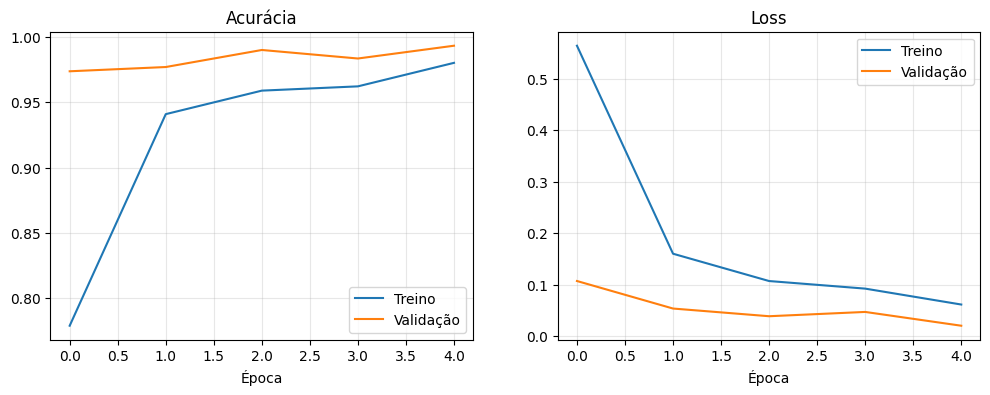

In [28]:
# CÉLULA 8: Verificando os resultados

loss, acuracia = modelo.evaluate(val_ds, verbose=0)
print(f"Acurácia na validação: {acuracia:.2%}")
print(f"Loss na validação: {loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico.history['accuracy'], label='Treino')
ax1.plot(historico.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia')
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historico.history['loss'], label='Treino')
ax2.plot(historico.history['val_loss'], label='Validação')
ax2.set_title('Loss')
ax2.set_xlabel('Época')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

In [39]:
# CÉLULA 9: Calculando a severidade da doença
# Essa parte eu desenvolvi pensando na prática de campo

def calcular_severidade(imagem):
    """
    Calcula a porcentagem da folha que está afetada.
    Na prática, um agrônomo faria essa estimativa visualmente.
    """
    img_uint8 = ((imagem + 1) * 127.5).astype(np.uint8)
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)

    # Isolando a folha (tons de verde)
    verde_baixo = np.array([35, 40, 40])
    verde_alto = np.array([85, 255, 255])
    mascara_folha = cv2.inRange(hsv, verde_baixo, verde_alto)

    # Isolando os sintomas (tons de marrom/amarelo)
    sintoma_baixo = np.array([10, 50, 50])
    sintoma_alto = np.array([30, 255, 200])
    mascara_sintomas = cv2.inRange(hsv, sintoma_baixo, sintoma_alto)

    # Calculando a proporção
    area_folha = np.sum(mascara_folha > 0)
    area_sintomas = np.sum(mascara_sintomas > 0)

    severidade = (area_sintomas / area_folha * 100) if area_folha > 0 else 0

    return severidade, mascara_folha, mascara_sintomas

In [57]:
# CÉLULA 10 (EXTRA): Função de recomendação agronômica

def recomendar_acao(severidade, doenca):
    """
    Converte a análise técnica em uma recomendação prática
    Baseado em critérios agronômicos reais
    """
    if severidade < 10:
        return {
            'nivel': 'Saudável',
            'acao': 'Monitoramento de rotina',
            'prazo': 'Verificar novamente em 7 dias',
            'cor': 'green',
            'icone': '🟢',
            'justificativa': 'Planta com boa capacidade de defesa natural, sem risco imediato'
        }
    elif severidade < 30:
        return {
            'nivel': 'Alerta',
            'acao': 'Aplicação preventiva',
            'prazo': 'Próximas 48 horas',
            'cor': 'orange',
            'icone': '🟡',
            'justificativa': 'Início do desenvolvimento da doença. Momento ideal para controle preventivo.'
        }
    elif severidade < 60:
        return {
            'nivel': 'Crítico',
            'acao': 'Intervenção curativa',
            'prazo': 'Próximas 24 horas',
            'cor': 'darkorange',
            'icone': '🟠',
            'justificativa': 'Doença já estabelecida. Risco de perda de produtividade se não tratada.'
        }
    else:
        return {
            'nivel': 'Perda',
            'acao': 'Remoção da planta',
            'prazo': 'Imediato',
            'cor': 'red',
            'icone': '🔴',
            'justificativa': 'Foco de contaminação. Remover para proteger plantas vizinhas.'
        }

def gerar_relatorio(doenca, confianca, severidade):
    """
    Gera um relatório completo no formato agronômico
    """
    recomendacao = recomendar_acao(severidade, doenca)

    relatorio = f"""

                   RELATÓRIO DE DIAGNÓSTICO AGRONÔMICO
     ══════════════════════════════════════════════════════════════

    DIAGNÓSTICO
    ────────────────────────────────────────────────────────────────
    Doença identificada: {doenca}
    Confiança: {confianca:.1f}%
    Severidade: {severidade:.1f}% da área foliar afetada

    CLASSIFICAÇÃO DE RISCO
    ────────────────────────────────────────────────────────────────
    Nível: {recomendacao['icone']} {recomendacao['nivel']}
    Ação recomendada: {recomendacao['acao']}
    Prazo: {recomendacao['prazo']}

    JUSTIFICATIVA TÉCNICA
    ────────────────────────────────────────────────────────────────
    {recomendacao['justificativa']}

    ════════════════════════════════════════════════════════════════
    """
    return relatorio, recomendacao

print("Sistema de recomendação agronômica carregado!")
print("   - 4 níveis de severidade")
print("   - Ação recomendada com prazo")
print("   - Justificativa técnica")

Sistema de recomendação agronômica carregado!
   - 4 níveis de severidade
   - Ação recomendada com prazo
   - Justificativa técnica


Testando o modelo...


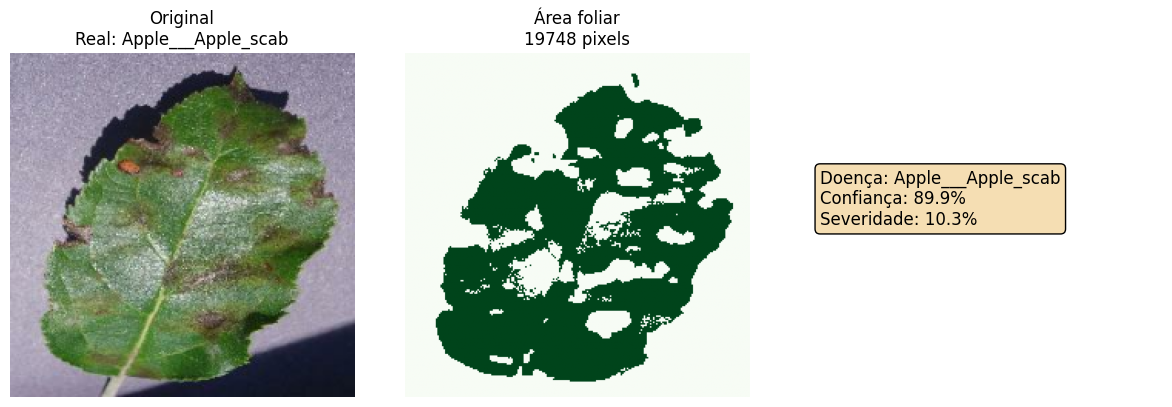

Imagem 1: Real=Apple___Apple_scab | Predito=Apple___Apple_scab | Severidade=10.3%


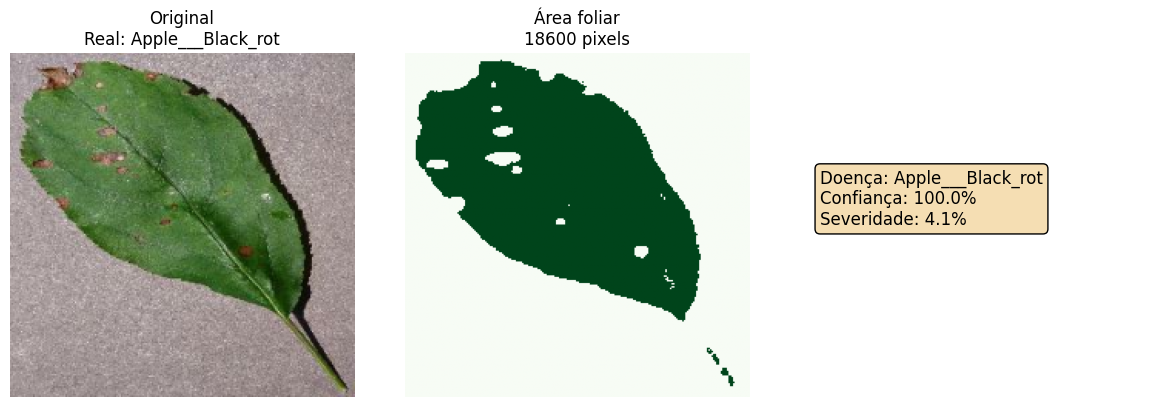

Imagem 2: Real=Apple___Black_rot | Predito=Apple___Black_rot | Severidade=4.1%


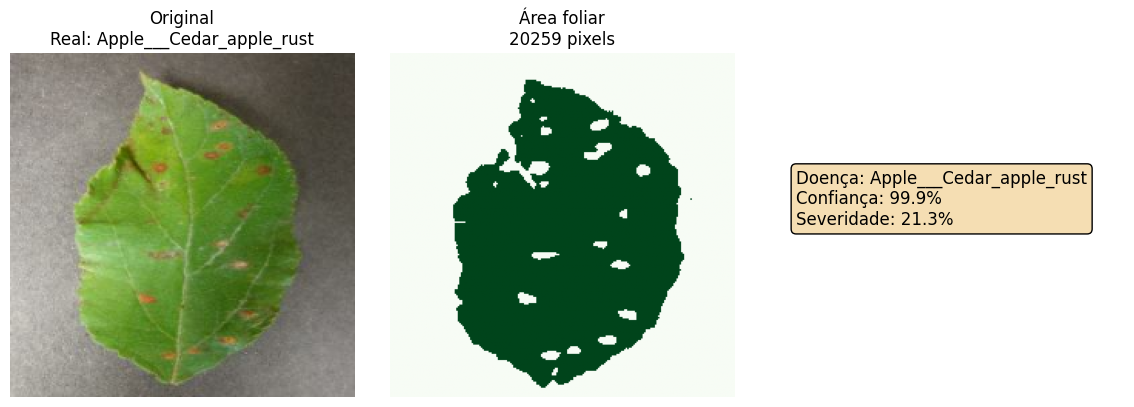

Imagem 3: Real=Apple___Cedar_apple_rust | Predito=Apple___Cedar_apple_rust | Severidade=21.3%


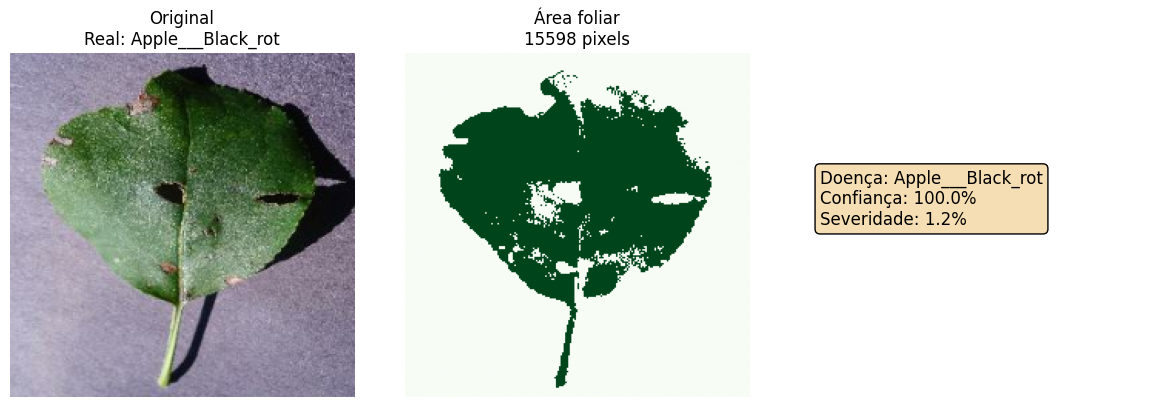

Imagem 4: Real=Apple___Black_rot | Predito=Apple___Black_rot | Severidade=1.2%


In [54]:
# CÉLULA 11: Testando com algumas imagens (classificação básica)

print("Testando o modelo...")

for imagens_batch, labels_batch in val_ds.take(1):
    for i in range(min(4, len(imagens_batch))):
        img = imagens_batch[i].numpy()
        classe_real = np.argmax(labels_batch[i].numpy())

        pred = modelo.predict(tf.expand_dims(img, 0), verbose=0)
        classe_pred = np.argmax(pred)
        confianca = np.max(pred) * 100

        severidade, mask_folha, mask_sintomas = calcular_severidade(img)

        img_display = ((img + 1) * 127.5).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(img_display)
        axes[0].set_title(f"Original\nReal: {CLASSES_SELECIONADAS[classe_real]}")
        axes[0].axis('off')

        axes[1].imshow(mask_folha, cmap='Greens')
        axes[1].set_title(f"Área foliar\n{np.sum(mask_folha>0)} pixels")
        axes[1].axis('off')

        axes[2].axis('off')
        resultado = f"Doença: {CLASSES_SELECIONADAS[classe_pred]}\n"
        resultado += f"Confiança: {confianca:.1f}%\n"
        resultado += f"Severidade: {severidade:.1f}%"
        axes[2].text(0.1, 0.5, resultado, fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='wheat'))

        plt.tight_layout()
        plt.show()

        print(f"Imagem {i+1}: Real={CLASSES_SELECIONADAS[classe_real]} | Predito={CLASSES_SELECIONADAS[classe_pred]} | Severidade={severidade:.1f}%")

TESTE COM RECOMENDAÇÕES AGRONÔMICAS

    
                   RELATÓRIO DE DIAGNÓSTICO AGRONÔMICO             
     ══════════════════════════════════════════════════════════════

    DIAGNÓSTICO
    ────────────────────────────────────────────────────────────────
    Doença identificada: Apple___Apple_scab
    Confiança: 89.9%
    Severidade: 10.3% da área foliar afetada

    CLASSIFICAÇÃO DE RISCO
    ────────────────────────────────────────────────────────────────
    Nível: 🟡 Alerta
    Ação recomendada: Aplicação preventiva
    Prazo: Próximas 48 horas

    JUSTIFICATIVA TÉCNICA
    ────────────────────────────────────────────────────────────────
    Início do desenvolvimento da doença. Momento ideal para controle preventivo.

    ════════════════════════════════════════════════════════════════
    


/tmp/ipykernel_7732/3883805505.py:63: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


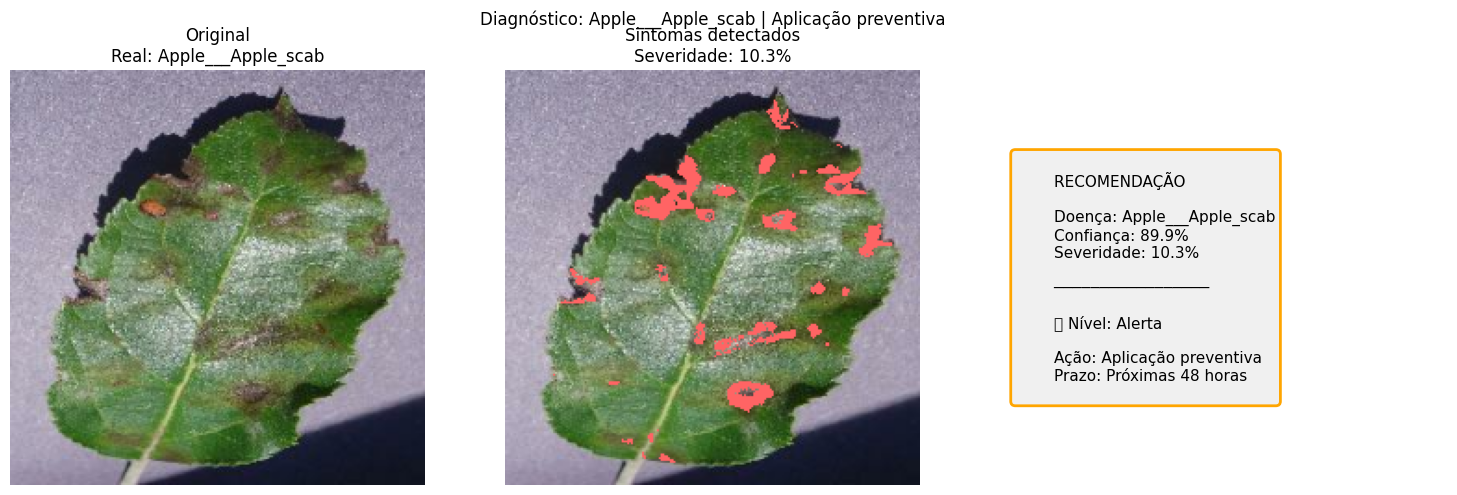

------------------------------------------------------------

    
                   RELATÓRIO DE DIAGNÓSTICO AGRONÔMICO             
     ══════════════════════════════════════════════════════════════

    DIAGNÓSTICO
    ────────────────────────────────────────────────────────────────
    Doença identificada: Apple___Black_rot
    Confiança: 100.0%
    Severidade: 4.1% da área foliar afetada

    CLASSIFICAÇÃO DE RISCO
    ────────────────────────────────────────────────────────────────
    Nível: 🟢 Saudável
    Ação recomendada: Monitoramento de rotina
    Prazo: Verificar novamente em 7 dias

    JUSTIFICATIVA TÉCNICA
    ────────────────────────────────────────────────────────────────
    Planta com boa capacidade de defesa natural, sem risco imediato

    ════════════════════════════════════════════════════════════════
    


/tmp/ipykernel_7732/3883805505.py:63: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


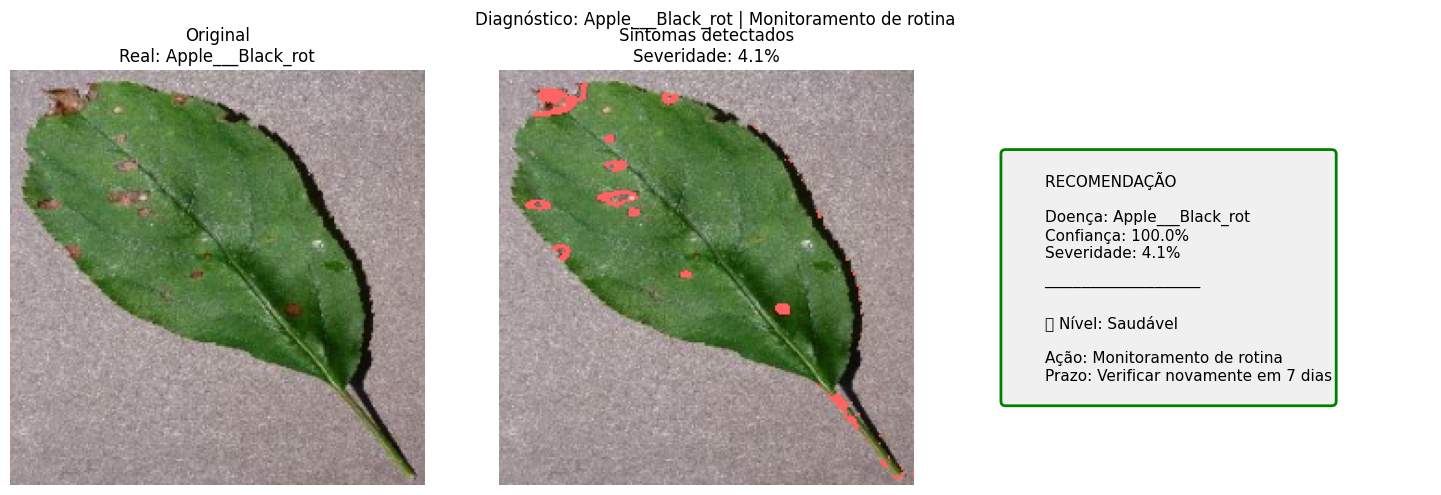

------------------------------------------------------------

    
                   RELATÓRIO DE DIAGNÓSTICO AGRONÔMICO             
     ══════════════════════════════════════════════════════════════

    DIAGNÓSTICO
    ────────────────────────────────────────────────────────────────
    Doença identificada: Apple___Cedar_apple_rust
    Confiança: 99.9%
    Severidade: 21.3% da área foliar afetada

    CLASSIFICAÇÃO DE RISCO
    ────────────────────────────────────────────────────────────────
    Nível: 🟡 Alerta
    Ação recomendada: Aplicação preventiva
    Prazo: Próximas 48 horas

    JUSTIFICATIVA TÉCNICA
    ────────────────────────────────────────────────────────────────
    Início do desenvolvimento da doença. Momento ideal para controle preventivo.

    ════════════════════════════════════════════════════════════════
    


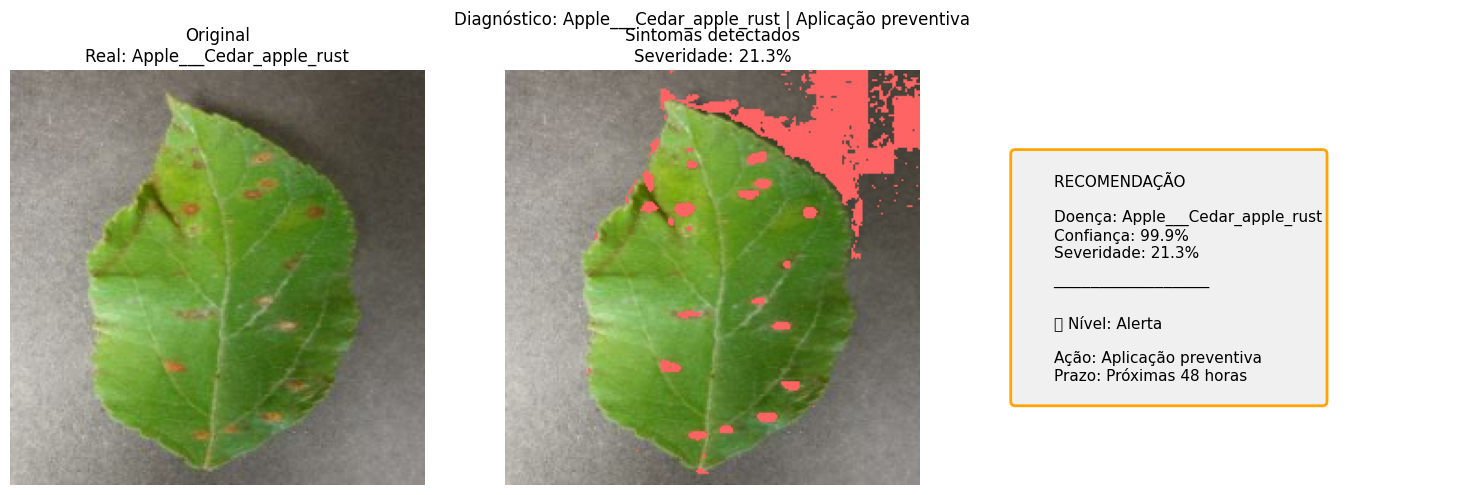

------------------------------------------------------------
Teste com recomendações concluído!


In [58]:
# CÉLULA 12: Teste com recomendações agronômicas

print("="*60)
print("TESTE COM RECOMENDAÇÕES AGRONÔMICAS")
print("="*60)

for imagens_batch, labels_batch in val_ds.take(1):
    for i in range(min(3, len(imagens_batch))):
        img = imagens_batch[i].numpy()
        classe_real = np.argmax(labels_batch[i].numpy())

        pred = modelo.predict(tf.expand_dims(img, 0), verbose=0)
        classe_pred = np.argmax(pred)
        confianca = np.max(pred) * 100

        severidade, mask_folha, mask_sintomas = calcular_severidade(img)

        # Gerar relatório com recomendação (usando a função que você já tem)
        relatorio, recomendacao = gerar_relatorio(
            CLASSES_SELECIONADAS[classe_pred],
            confianca,
            severidade
        )

        print(relatorio)

        img_display = ((img + 1) * 127.5).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img_display)
        axes[0].set_title(f"Original\nReal: {CLASSES_SELECIONADAS[classe_real]}")
        axes[0].axis('off')

        overlay = img_display.copy()
        overlay[mask_sintomas > 0] = [255, 100, 100]
        axes[1].imshow(overlay)
        axes[1].set_title(f"Sintomas detectados\nSeveridade: {severidade:.1f}%")
        axes[1].axis('off')

        axes[2].axis('off')
        texto_recomendacao = f"""
        RECOMENDAÇÃO

        Doença: {CLASSES_SELECIONADAS[classe_pred]}
        Confiança: {confianca:.1f}%
        Severidade: {severidade:.1f}%

        ─────────────────

        {recomendacao['icone']} Nível: {recomendacao['nivel']}

        Ação: {recomendacao['acao']}
        Prazo: {recomendacao['prazo']}
        """
        axes[2].text(0.1, 0.5, texto_recomendacao, fontsize=11,
                    verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='#f0f0f0',
                             edgecolor=recomendacao['cor'], linewidth=2))

        plt.suptitle(f"Diagnóstico: {CLASSES_SELECIONADAS[classe_pred]} | {recomendacao['acao']}",
                    fontsize=12)
        plt.tight_layout()
        plt.show()

        print("-"*60)

print("Teste com recomendações concluído!")

In [42]:
# CÉLULA 13: Salvando o modelo treinado

print("Salvando o modelo...")

modelo.save('modelo_doencas_plantas.keras')
print("Modelo salvo como 'modelo_doencas_plantas.keras'")

import json
with open('classes.json', 'w') as f:
    json.dump({'classes': CLASSES_SELECIONADAS}, f)
print("Nomes das classes salvos")

from google.colab import files
files.download('modelo_doencas_plantas.keras')
files.download('classes.json')

print("Download concluído")

Salvando o modelo...
Modelo salvo como 'modelo_doencas_plantas.keras'
Nomes das classes salvos


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download concluído


In [43]:
# CÉLULA 14: Criando uma função para usar o modelo em novas imagens

def analisar_planta(caminho_imagem):
    """
    Função que analisa uma imagem e retorna diagnóstico
    """
    img = cv2.imread(caminho_imagem)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_redimensionada = cv2.resize(img_rgb, (224, 224))
    img_processada = tf.keras.applications.mobilenet_v2.preprocess_input(img_redimensionada.astype(np.float32))

    pred = modelo.predict(tf.expand_dims(img_processada, 0), verbose=0)
    classe = CLASSES_SELECIONADAS[np.argmax(pred)]
    confianca = np.max(pred) * 100

    severidade, _, _ = calcular_severidade(img_processada)

    print(f"Doença detectada: {classe}")
    print(f"Confiança: {confianca:.1f}%")
    print(f"Severidade: {severidade:.1f}%")

    return {'doenca': classe, 'confianca': confianca, 'severidade': severidade}

In [45]:
# CÉLULA 15: Salvar modelo e baixar para o computador
print("\n" + "="*70)
print("SALVANDO MODELO TREINADO")
print("="*70)

# Salvar modelo no formato Keras nativo
model.save('plant_disease_model.keras')
print("Modelo salvo como 'plant_disease_model.keras'")

# Salvar também no formato H5 para compatibilidade
model.save('plant_disease_model.h5')
print("Modelo salvo como 'plant_disease_model.h5'")

# Salvar os nomes das classes em um arquivo
import json
class_names_dict = {'classes': CLASS_NAMES}
with open('class_names.json', 'w') as f:
    json.dump(class_names_dict, f)
print("Nomes das classes salvos em 'class_names.json'")

# Criar um arquivo de informações do modelo
info_modelo = f"""
Informações do Modelo Treinado
{'='*50}

Dataset: PlantVillage
Classes: {CLASS_NAMES}
Número de classes: {len(CLASS_NAMES)}
Acurácia de validação: {val_acc:.2%}
Loss de validação: {val_loss:.4f}

Arquitetura:
- Base: MobileNetV2 (pré-treinado ImageNet)
- Camadas adicionais: GlobalAveragePooling2D, Dropout(0.3), Dense(128), Dropout(0.5), Dense({len(CLASS_NAMES)})
- Otimizador: Adam (lr=0.001)
- Função de perda: categorical_crossentropy

Data de treinamento: {__import__('datetime').datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open('model_info.txt', 'w') as f:
    f.write(info_modelo)
print("Informações do modelo salvas em 'model_info.txt'")

# Criar um arquivo ZIP com tudo
import zipfile
import os

print("\n Criando arquivo ZIP com todos os arquivos...")
with zipfile.ZipFile('plant_disease_model_completo.zip', 'w') as zipf:
    zipf.write('plant_disease_model.keras')
    zipf.write('plant_disease_model.h5')
    zipf.write('class_names.json')
    zipf.write('model_info.txt')

print("ZIP criado: 'plant_disease_model_completo.zip'")

# Mostrar tamanho dos arquivos
print("\n Tamanho dos arquivos:")
import os
for file in ['plant_disease_model.keras', 'plant_disease_model.h5', 'class_names.json', 'model_info.txt', 'plant_disease_model_completo.zip']:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"   {file}: {size:.2f} MB")

# Baixar para o computador
from google.colab import files

print("\n Iniciando download dos arquivos...")

print("\n1. Baixando modelo Keras (.keras)...")
files.download('plant_disease_model.keras')

print("\n2. Baixando modelo H5 (.h5)...")
files.download('plant_disease_model.h5')

print("\n3. Baixando nomes das classes...")
files.download('class_names.json')

print("\n4. Baixando informações do modelo...")
files.download('model_info.txt')

print("\n5. Baixando pacote completo (ZIP)...")
files.download('plant_disease_model_completo.zip')

print("\n" + "="*70)
print("DOWNLOAD CONCLUÍDO!")
print("="*70)
print("\n Arquivos baixados:")
print("plant_disease_model.keras - Modelo no formato Keras nativo (recomendado)")
print("plant_disease_model.h5 - Modelo em formato H5 (compatível)")
print("class_names.json - Nomes das classes")
print("model_info.txt - Informações técnicas")
print("plant_disease_model_completo.zip - Pacote completo")
print("\n Usar arquivo .keras para carregar o modelo com TensorFlow/Keras")


SALVANDO MODELO TREINADO


Modelo salvo como 'plant_disease_model.keras'
Modelo salvo como 'plant_disease_model.h5'
Nomes das classes salvos em 'class_names.json'
Informações do modelo salvas em 'model_info.txt'

 Criando arquivo ZIP com todos os arquivos...
ZIP criado: 'plant_disease_model_completo.zip'

 Tamanho dos arquivos:
   plant_disease_model.keras: 11.06 MB
   plant_disease_model.h5: 10.85 MB
   class_names.json: 0.00 MB
   model_info.txt: 0.00 MB
   plant_disease_model_completo.zip: 21.91 MB

 Iniciando download dos arquivos...

1. Baixando modelo Keras (.keras)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


2. Baixando modelo H5 (.h5)...


...

<IPython.core.display.Javascript object>


5. Baixando pacote completo (ZIP)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DOWNLOAD CONCLUÍDO!

 Arquivos baixados:
plant_disease_model.keras - Modelo no formato Keras nativo (recomendado)
plant_disease_model.h5 - Modelo em formato H5 (compatível)
class_names.json - Nomes das classes
model_info.txt - Informações técnicas
plant_disease_model_completo.zip - Pacote completo

 Usar arquivo .keras para carregar o modelo com TensorFlow/Keras
